**Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None) # display all columns

In [2]:
df = pd.read_csv("/content/train.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
df.shape

(45593, 20)

In [4]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [7]:
df.describe(exclude = np.number).T

,count,unique,top,freq
ID,45593,45593,0x5fb2,1
Delivery_person_ID,45593,1320,JAPRES11DEL02,67
Delivery_person_Age,45593,23,35,2262
Delivery_person_Ratings,45593,29,4.8,7148
Order_Date,45593,44,15-03-2022,1192
Time_Orderd,45593,177,NaN,1731
Time_Order_picked,45593,193,21:30:00,496
Weatherconditions,45593,7,conditions Fog,7654
Road_traffic_density,45593,5,Low,15477
Type_of_order,45593,4,Snack,11533


<h2>Observations</h2>

Latitude and longitude features can be used to calculate the distance between the restaurant and delivery location.

Most deliveries are made in Metropolitian cities, indicating the dataset is dominated by urban orders.

Motorcycles are the most frequently used delivery vehicle in the dataset.

Low traffic density is the most common traffic condition among all orders.

Most orders involve one multiple delivery, suggesting single-stop deliveries are more common.

Vehicle_condition ranges from 0 to 3, indicating different vehicle conditions that may affect delivery time.

Festival is mostly No, meaning festive-day deliveries are relatively rare in the dataset.

The target variable Time_taken(min) requires data cleaning to extract numeric values before model training.

In [8]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values

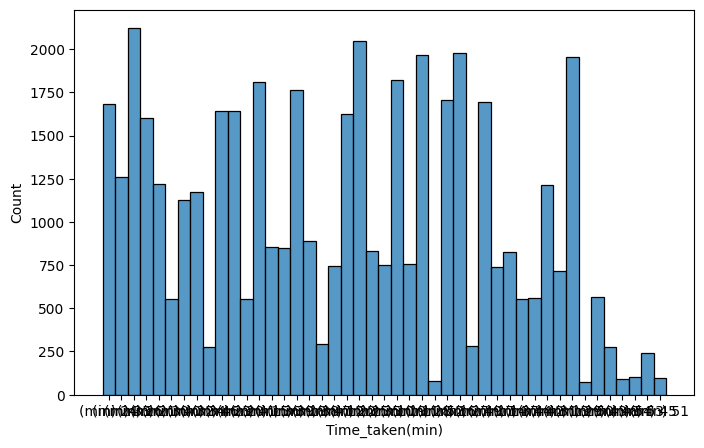

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time_taken(min)"], bins=30)

plt.show()

In [10]:
#Explore each column
for column in df.columns:
    print(column)
    print(df[column].value_counts())
    print("---------------------------------")


ID
ID
0x5fb2     1
0x4607     1
0xb379     1
0x5d6d     1
0x7a6a     1
          ..
0x3c5e     1
0x3e60     1
0xbff      1
0xd936     1
0xd681     1
Name: count, Length: 45593, dtype: int64
---------------------------------
Delivery_person_ID
Delivery_person_ID
JAPRES11DEL02        67
PUNERES01DEL01       67
RANCHIRES02DEL01     66
VADRES08DEL02        66
JAPRES03DEL01        66
                     ..
BHPRES15DEL03         7
AURGRES13DEL03        7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64
---------------------------------
Delivery_person_Age
Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
---------------------------------
D

Data Cleaning

In [11]:
#Extract relevant values from column
def extract_column_value(df):
    #Extract time_teaken and convert to int
    df["Time_taken(min)"]=df["Time_taken(min)"].apply(lambda x: int(x.split(' ')[1].strip()))
    #Extract Weather conditions
    df["Weatherconditions"]=df["Weatherconditions"].apply(lambda x: x.split(' ')[1].strip())
    #Extract city code from Delivery person ID
    df["City_code"]=df["Delivery_person_ID"].str.split("RES", expand=True)[0]
extract_column_value(df)
df[["Time_taken(min)", "Weatherconditions", "City_code"]].head()

,Time_taken(min),Weatherconditions,City_code
0,24,Sunny,INDO
1,33,Stormy,BANG
2,26,Sandstorms,BANG
3,21,Sunny,COIMB
4,30,Cloudy,CHEN


In [12]:
#Drop irrelevant Columns
def drop_columns(df):
    df.drop(['ID', 'Delivery_person_ID'], axis=1, inplace=True)
print("Before columns: ", df.shape[1])
drop_columns(df)
print("After columns: ", df.shape[1])

Before columns:  21
After columns:  19


In [13]:
#Update datatypes
def update_datatype(df):
    df["Delivery_person_Age"]=df["Delivery_person_Age"].astype("float64")
    df["Delivery_person_Ratings"]=df["Delivery_person_Ratings"].astype("float64")
    df["multiple_deliveries"]=df["multiple_deliveries"].astype("float64")
    df['Order_Date']=pd.to_datetime(df['Order_Date'],format="%d-%m-%Y")

update_datatype(df)

In [14]:
# Check null values
df.isnull().sum()

,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Weatherconditions,0


In [15]:
#Convert String 'NaN' to np.nan
def convert_nan(df):
    df.replace("NaN", float(np.nan), regex=True, inplace=True)

convert_nan(df)

In [16]:
df.isnull().sum()

,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731
Time_Order_picked,0
Weatherconditions,616


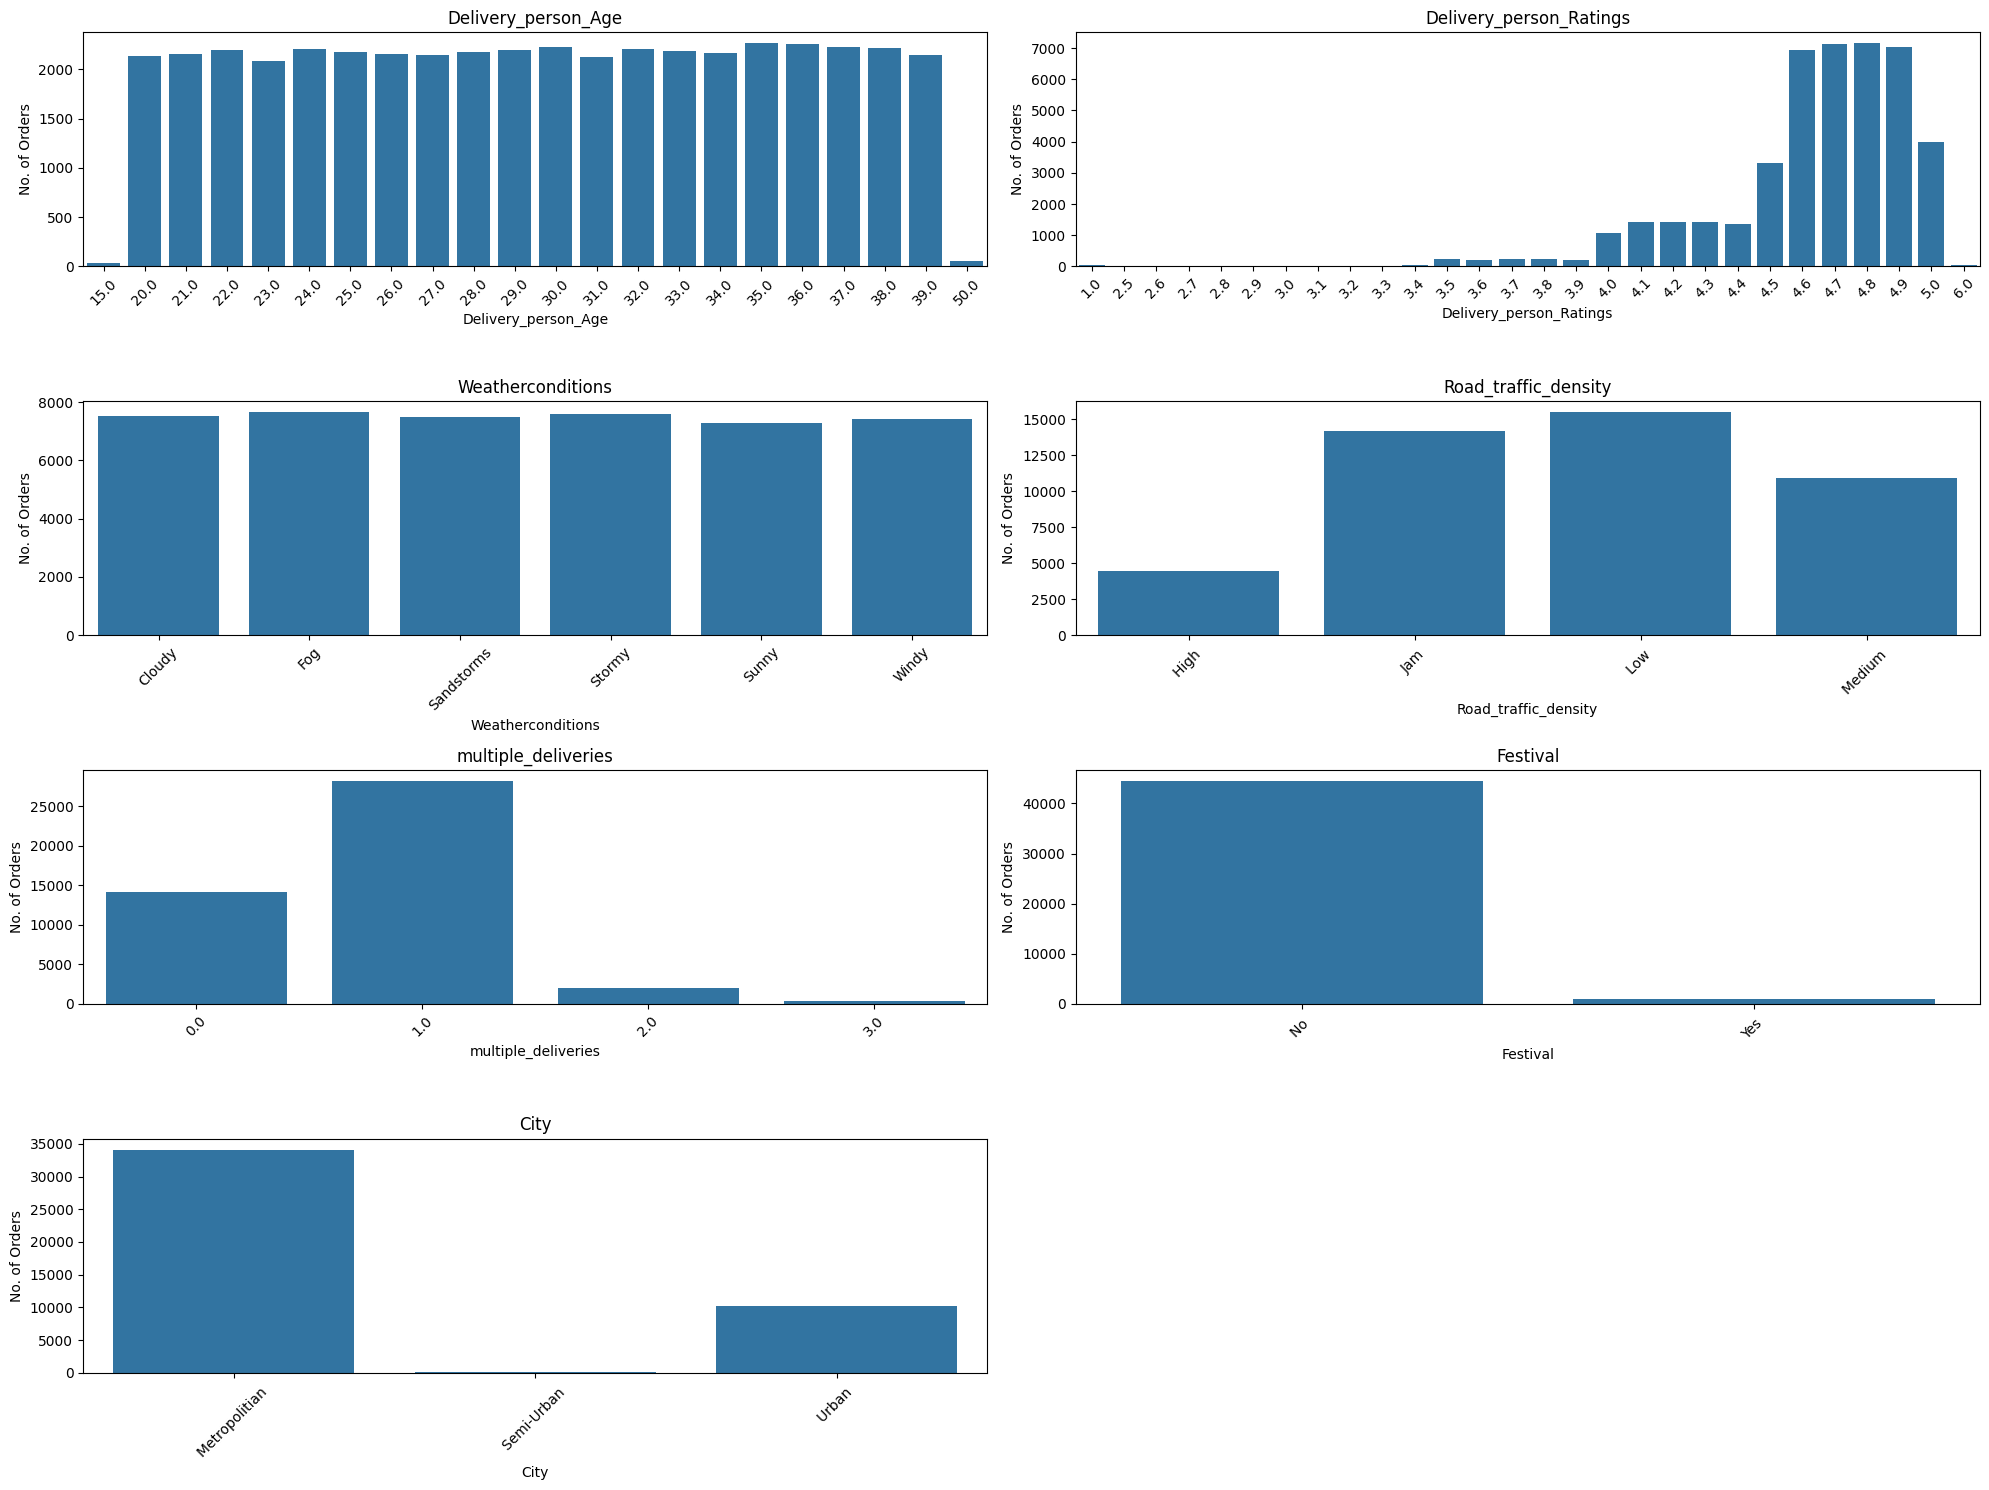

In [17]:
# Explore the columns that have null values
cols = ['Delivery_person_Age','Delivery_person_Ratings','Weatherconditions','Road_traffic_density','multiple_deliveries','Festival','City']
num_plots = len(cols)
num_rows = (num_plots // 2) + (num_plots % 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(20,15))

for i, column_name in enumerate(cols):
    row = i // 2
    col = i % 2

    ax = axes[row, col]
    sns.countplot(data=df, x=column_name, order=df[column_name].value_counts().sort_index().index, ax=ax)

    ax.set_xlabel(column_name)
    ax.set_ylabel('No. of Orders')
    ax.set_title(column_name)
    ax.tick_params(axis='x', rotation=45)

if num_plots % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

In [18]:
# Handle null values
def handle_null_values(df):

    df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(np.random.choice(df["Delivery_person_Age"]))
    df["Weatherconditions"] = df["Weatherconditions"].fillna(np.random.choice(df["Weatherconditions"]))
    df["City"] = df["City"].fillna(df["City"].mode()[0])
    df["Festival"] = df["Festival"].fillna(df["Festival"].mode()[0])
    df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].mode()[0])
    df["Road_traffic_density"] = df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0])
    df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())

# Apply the function to df_train
handle_null_values(df)

# Check for remaining null values
df.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731
Time_Order_picked,0
Weatherconditions,0


<H1>Feature Engineering</H1>

In [19]:
def extract_date_features(data):
    data["day"] = data.Order_Date.dt.day
    data["month"] = data.Order_Date.dt.month
    data["quarter"] = data.Order_Date.dt.quarter
    data["year"] = data.Order_Date.dt.year
    data['day_of_week'] = data.Order_Date.dt.day_of_week.astype(int)
    data["is_month_start"] = data.Order_Date.dt.is_month_start.astype(int)
    data["is_month_end"] = data.Order_Date.dt.is_month_end.astype(int)
    data["is_quarter_start"] = data.Order_Date.dt.is_quarter_start.astype(int)
    data["is_quarter_end"] = data.Order_Date.dt.is_quarter_end.astype(int)
    data["is_year_start"] = data.Order_Date.dt.is_year_start.astype(int)
    data["is_year_end"] = data.Order_Date.dt.is_year_end.astype(int)
    data['is_weekend'] = np.where(data['day_of_week'].isin([5,6]),1,0)

extract_date_features(df)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,BANG,19,3,1,2022,5,0,0,0,0,0,0,1
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,COIMB,5,4,2,2022,1,0,0,0,0,0,0,0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,CHEN,26,3,1,2022,5,0,0,0,0,0,0,1


In [20]:
def calculate_time_diff(df):
    # Convert the time columns to timedelta
    df['Time_Orderd'] = pd.to_timedelta(df['Time_Orderd'])
    df['Time_Order_picked'] = pd.to_timedelta(df['Time_Order_picked'])

    # Correctly format the picked time, handling cases where picked time is on the next day
    df['Time_Order_picked_formatted'] = df['Order_Date'] + df['Time_Order_picked']
    mask = df['Time_Order_picked'] < df['Time_Orderd']
    df.loc[mask, 'Time_Order_picked_formatted'] += pd.DateOffset(days=1)

    # Format the ordered time
    df['Time_Ordered_formatted'] = df['Order_Date'] + df['Time_Orderd']

    # Calculate the order preparation time in minutes
    df['order_prepare_time'] = (df['Time_Order_picked_formatted'] - df['Time_Ordered_formatted']).dt.total_seconds() / 60

    # Handle null values by assigning the result of fillna() to the column explicitly
    df['order_prepare_time'] = df['order_prepare_time'].fillna(df['order_prepare_time'].median())

    # Drop all the time & date related columns
    df.drop(['Time_Orderd', 'Time_Order_picked', 'Time_Ordered_formatted', 'Time_Order_picked_formatted', 'Order_Date'], axis=1, inplace=True)

# Assuming df_train is your DataFrame
calculate_time_diff(df)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0,5.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,BANG,19,3,1,2022,5,0,0,0,0,0,0,1,15.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,COIMB,5,4,2,2022,1,0,0,0,0,0,0,0,10.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,CHEN,26,3,1,2022,5,0,0,0,0,0,0,1,15.0


In [21]:
# Calculate distance between restaurant location & delivery location using geopy library
from geopy.distance import geodesic

def calculate_distance(df):
    # Initialize the distance column with zeros
    df["distance"] = np.zeros(len(df))

    # Get the restaurant and delivery coordinates as numpy arrays
    restaurant_coordinates = df[['Restaurant_latitude', 'Restaurant_longitude']].to_numpy()
    delivery_location_coordinates = df[['Delivery_location_latitude', 'Delivery_location_longitude']].to_numpy()

    # Calculate geodesic distance between restaurant and delivery locations
    df["distance"] = np.array([geodesic(restaurant, delivery).kilometers for restaurant, delivery in zip(restaurant_coordinates, delivery_location_coordinates)])

    # Extract numeric part from the distance
    df["distance"] = df["distance"].astype("str").str.extract(r'(\d+)').astype("int64")

    df.drop(['Restaurant_latitude', 'Restaurant_longitude','Delivery_location_latitude', 'Delivery_location_longitude'], axis=1, inplace=True)

# Apply the function to df_train
calculate_distance(df)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,3
1,34.0,4.5,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0,5.0,20
2,23.0,4.4,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,BANG,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,1
3,38.0,4.7,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,COIMB,5,4,2,2022,1,0,0,0,0,0,0,0,10.0,7
4,32.0,4.6,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,CHEN,26,3,1,2022,5,0,0,0,0,0,0,1,15.0,6


<H1>Data Preprocessing
<H2>Label Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder
def label_encoding(df):
    categorical_columns = df.select_dtypes(include='object').columns
    le = LabelEncoder()
    df[categorical_columns] = df[categorical_columns].apply(lambda col: le.fit_transform(col))

label_encoding(df)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,4,0,2,3,2,0.0,0,2,24,10,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,3
1,34.0,4.5,3,1,2,3,3,1.0,0,0,33,3,25,3,1,2022,4,0,0,0,0,0,0,0,5.0,20
2,23.0,4.4,2,2,0,1,2,1.0,0,2,26,3,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,1
3,38.0,4.7,4,3,0,0,2,1.0,0,0,21,6,5,4,2,2022,1,0,0,0,0,0,0,0,10.0,7
4,32.0,4.6,0,0,1,3,3,1.0,0,0,30,5,26,3,1,2022,5,0,0,0,0,0,0,1,15.0,6


In [23]:
print(df.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)', 'City_code', 'day', 'month', 'quarter', 'year', 'day_of_week', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'is_weekend', 'order_prepare_time', 'distance']


In [24]:
# Check the column names and strip any leading/trailing whitespace
df.columns = df.columns.str.strip()

In [25]:
X = df.drop('Time_taken(min)', axis=1)
y = df['Time_taken(min)']

<H2>Train test split

In [26]:
# Split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36474, 25)
(36474,)
(9119, 25)
(9119,)


<H2>Standardization

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

<H1>Model Building

<H2>Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

models=[
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    xgb.XGBRegressor(),
]

param_grid=[
    {},
    {"max_depth":[3,5,7]},
    {"n_estimators":[100,200,300]},
    {"n_estimators":[20, 25, 30], "max_depth":[5,7,9]}
]

for i, model in enumerate(models):
    grid_search=GridSearchCV(model, param_grid[i], cv=5, scoring="r2")
    grid_search.fit(X_train, y_train)
    print(f"{model.__class__.__name__}")
    print("Best parameters: ", grid_search.best_params_)
    print("R2 score: ",grid_search.best_score_)
    print()

LinearRegression
Best parameters:  {}
R2 score:  0.41236608496203153

DecisionTreeRegressor
Best parameters:  {'max_depth': 7}
R2 score:  0.7172679748532118

RandomForestRegressor
Best parameters:  {'n_estimators': 300}
R2 score:  0.8139464864472276

XGBRegressor
Best parameters:  {'max_depth': 7, 'n_estimators': 20}
R2 score:  0.8220835208892823



<H2>Model Building

In [29]:
model=xgb.XGBRegressor(n_estimators=20, max_depth=9)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=None, num_parallel_tree=None, ...)

<H2>Model Evaluation

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae,2))
print("MSE:", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

MAE: 3.12
MSE: 15.46
RMSE: 3.93
R2 Score: 0.82


<H1> Conclusion</H1>
<p></p>

The Food Delivery ETA Prediction project successfully developed a machine learning model to estimate delivery times using various delivery-related features. Multiple regression algorithms were evaluated through cross-validation and hyperparameter tuning.

The results showed that:

Linear Regression achieved an R² score of 0.42, indicating that a simple linear model could not capture the complex relationships in the data.   
Decision Tree Regressor improved performance with an R² score of 0.73.  
Random Forest Regressor achieved an R² score of 0.82, demonstrating strong predictive capability.   
XGBoost Regressor delivered the best overall performance during model selection with a cross-validation R² score of approximately 0.82.

The final XGBoost model produced the following test results:

MAE: 3.12     
MSE: 15.44    
RMSE: 3.93     
R² Score: 0.82  

These metrics indicate that the model explains about 82% of the variance in delivery times while maintaining an average prediction error of only 3 to 4 minutes, making it a reliable solution for ETA prediction.   

Overall, this project demonstrates that ensemble learning methods, particularly XGBoost, are highly effective for food delivery time prediction. Such models can help delivery platforms improve customer satisfaction, optimize delivery operations, and provide more accurate estimated arrival times. Future improvements could include incorporating real-time traffic, weather conditions, driver behavior, and live order volume to further enhance prediction accuracy.